Program :-

In [ ]:
!pip install kagglehub tensorflow matplotlib -q

import os, json, random, warnings
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from google.colab import files
warnings.filterwarnings('ignore')

print('TensorFlow :', tf.__version__)
print('GPU        :', tf.config.list_physical_devices('GPU'))
print('✅ Ready!')

TensorFlow : 2.19.0
GPU        : []
✅ Ready!


In [ ]:
import kagglehub

# ✏️ Paste your Kaggle credentials here
import os
KAGGLE_USERNAME = os.getenv('KAGGLE_USERNAME')
KAGGLE_KEY = os.getenv('KAGGLE_KEY') # ← replace

kaggle_dir = os.path.expanduser('~/.kaggle')
os.makedirs(kaggle_dir, exist_ok=True)
with open(os.path.join(kaggle_dir, 'kaggle.json'), 'w') as f:
    json.dump({'username': KAGGLE_USERNAME, 'key': KAGGLE_KEY}, f)
os.chmod(os.path.join(kaggle_dir, 'kaggle.json'), 0o600)

path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")
print('✅ Dataset downloaded!')
print('📁 Path:', path)

Using Colab cache for faster access to the 'new-plant-diseases-dataset' dataset.
✅ Dataset downloaded!
📁 Path: /kaggle/input/new-plant-diseases-dataset


In [ ]:
def find_dir(base, name):
    for root, dirs, _ in os.walk(base):
        if name in dirs:
            return os.path.join(root, name)
    return None

TRAIN_DIR = find_dir(path, 'train')
VALID_DIR = find_dir(path, 'valid') or find_dir(path, 'val')

classes     = sorted(os.listdir(TRAIN_DIR))
NUM_CLASSES = len(classes)
total_train = sum(len(os.listdir(os.path.join(TRAIN_DIR, c))) for c in classes)

print(f'📁 Train : {TRAIN_DIR}')
print(f'📁 Valid : {VALID_DIR}')
print(f'✅ Classes     : {NUM_CLASSES}')
print(f'✅ Train images: {total_train:,}')

📁 Train : /kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train
📁 Valid : /kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid
✅ Classes     : 38
✅ Train images: 70,295


In [ ]:
IMG_SIZE   = (96, 96)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    VALID_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

class_names = list(train_gen.class_indices.keys())
print(f'✅ Train batches : {len(train_gen)}')
print(f'✅ Val   batches : {len(val_gen)}')

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.
✅ Train batches : 2197
✅ Val   batches : 550


In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(96, 96, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,624,742 (10.01 MB)

 Trainable params: 366,246 (1.40 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5,
                  restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', patience=3,
                      factor=0.5, verbose=1),
    tf.keras.callbacks.ModelCheckpoint('best_model.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]

print('🚀 Training Started...\n')

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=callbacks
)

print('\n✅ Training Complete!')

🚀 Training Started...

Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step - accuracy: 0.6205 - loss: 1.3304
Epoch 1: val_accuracy improved from None to 0.83889, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1083s 490ms/step - accuracy: 0.7331 - loss: 0.8880 - val_accuracy: 0.8389 - val_loss: 0.4816 - learning_rate: 0.0010
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step - accuracy: 0.8144 - loss: 0.5846
Epoch 2: val_accuracy improved from 0.83889 to 0.85830, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 809s 368ms/step - accuracy: 0.8216 - loss: 0.5595 - val_accuracy: 0.8583 - val_loss: 0.4452 - learning_rate: 0.0010
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step - accuracy: 0.8382 - loss: 0.5082
Epoch 3: val_accuracy improved from 0.85830 to 0.86570, saving model to best_model.keras

Epoch 3: finished saving model to best_mode

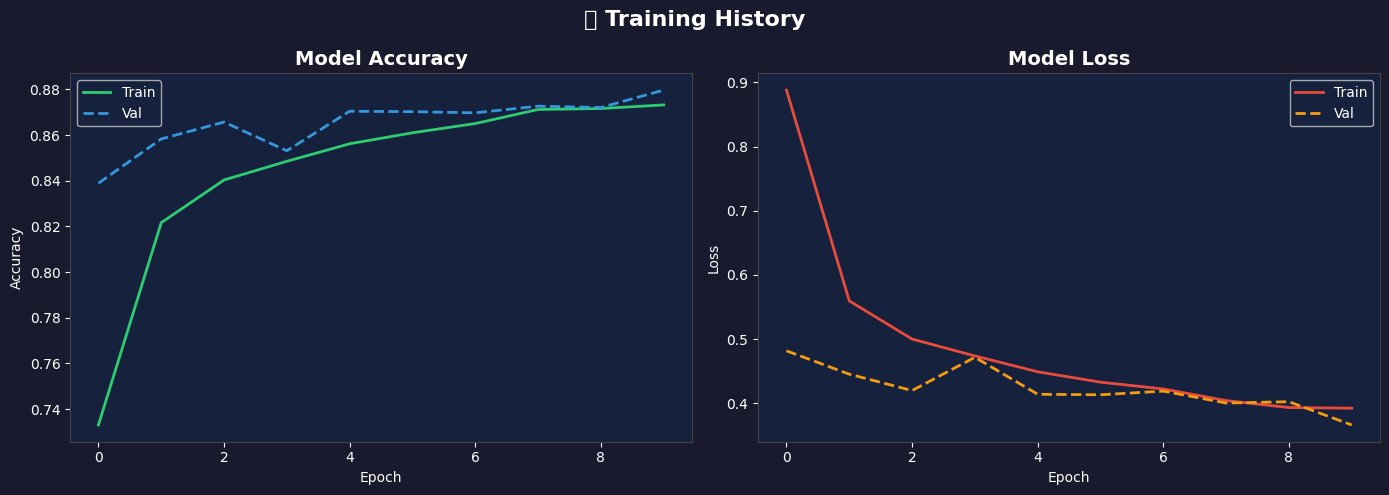

✅ Saved as training_history.png


In [ ]:
import matplotlib.pyplot as plt

if 'history' in locals() or 'history' in globals():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.patch.set_facecolor('#1a1a2e')

    for ax in axes:
        ax.set_facecolor('#16213e')
        for spine in ax.spines.values():
            spine.set_edgecolor('#444')

    axes[0].plot(history.history['accuracy'],     color='#2ecc71', lw=2, label='Train')
    axes[0].plot(history.history['val_accuracy'], color='#3498db', lw=2, label='Val', linestyle='--')
    axes[0].set_title('Model Accuracy', color='white', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch', color='white')
    axes[0].set_ylabel('Accuracy', color='white')
    axes[0].tick_params(colors='white')
    axes[0].legend(facecolor='#16213e', labelcolor='white')

    axes[1].plot(history.history['loss'],     color='#e74c3c', lw=2, label='Train')
    axes[1].plot(history.history['val_loss'], color='#f39c12', lw=2, label='Val', linestyle='--')
    axes[1].set_title('Model Loss', color='white', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch', color='white')
    axes[1].set_ylabel('Loss', color='white')
    axes[1].tick_params(colors='white')
    axes[1].legend(facecolor='#16213e', labelcolor='white')

    plt.suptitle('📈 Training History', fontsize=16, fontweight='bold', color='white')
    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150, facecolor='#1a1a2e')
    plt.show()
    print('✅ Saved as training_history.png')
else:
    print("Training history not found. Please ensure 'Step 6: Train the Model' has been successfully executed.")

📸 Upload a plant/leaf image:


Saving diseasebanner.jpg to diseasebanner.jpg


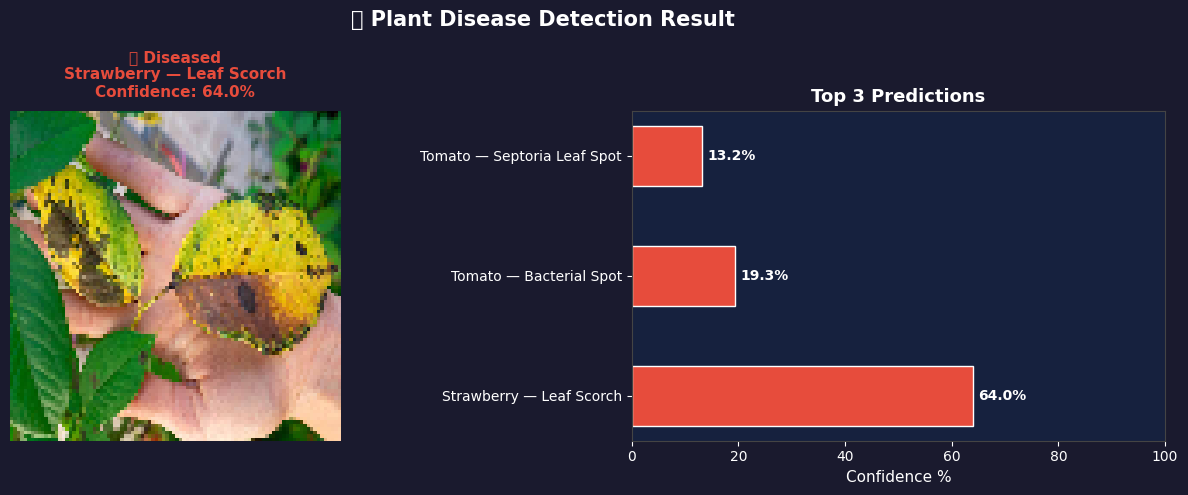


🌿 DETECTION RESULT
  Status    : 🚨 Diseased
  Disease   : Strawberry — Leaf Scorch
  Confidence: 64.02%

  Top 3 Predictions:
    1. Strawberry — Leaf Scorch                      64.02%
    2. Tomato — Bacterial Spot                       19.32%
    3. Tomato — Septoria Leaf Spot                   13.19%
✅ Saved as detection_result.png


In [ ]:
from google.colab import files

print('📸 Upload a plant/leaf image:')
uploaded = files.upload()

for image_path in uploaded.keys():

    # ── Load & preprocess ──────────────────────────────────────────────
    img = load_img(image_path, target_size=(96, 96))
    arr = np.expand_dims(img_to_array(img) / 255.0, axis=0)

    # ── Predict ────────────────────────────────────────────────────────
    pred        = model.predict(arr, verbose=0)[0]
    top3_idx    = pred.argsort()[-3:][::-1]
    top3        = [(class_names[i], pred[i] * 100) for i in top3_idx]

    best_label  = top3[0][0]
    best_conf   = top3[0][1]
    is_healthy  = 'healthy' in best_label.lower()
    status      = '✅ Healthy' if is_healthy else '🚨 Diseased'
    bar_color   = '#2ecc71'   if is_healthy else '#e74c3c'

    # ── Clean label for display ────────────────────────────────────────
    def clean(label):
        return label.replace('___', ' — ').replace('_', ' ').title()

    # ── Plot ───────────────────────────────────────────────────────────
    fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(13, 5))
    fig.patch.set_facecolor('#1a1a2e')

    # Left: image
    ax_img.imshow(img)
    ax_img.axis('off')
    ax_img.set_title(
        f'{status}\n{clean(best_label)}\nConfidence: {best_conf:.1f}%',
        color=bar_color, fontsize=11, fontweight='bold', pad=10
    )

    # Right: top-3 bar chart
    labels = [clean(r[0]) for r in top3]
    values = [r[1] for r in top3]
    colors = ['#2ecc71' if 'healthy' in r[0].lower() else '#e74c3c' for r in top3]

    ax_bar.set_facecolor('#16213e')
    bars = ax_bar.barh(labels, values, color=colors, edgecolor='white', height=0.5)
    ax_bar.set_xlim(0, 100)
    ax_bar.set_xlabel('Confidence %', color='white', fontsize=11)
    ax_bar.set_title('Top 3 Predictions', color='white',
                     fontsize=13, fontweight='bold')
    ax_bar.tick_params(colors='white')
    for spine in ax_bar.spines.values():
        spine.set_edgecolor('#444')
    for bar, val in zip(bars, values):
        ax_bar.text(val + 1, bar.get_y() + bar.get_height() / 2,
                    f'{val:.1f}%', va='center', color='white',
                    fontsize=10, fontweight='bold')

    plt.suptitle('🌿 Plant Disease Detection Result',
                 fontsize=15, fontweight='bold', color='white')
    plt.tight_layout()
    plt.savefig('detection_result.png', dpi=150, facecolor='#1a1a2e')
    plt.show()

    # ── Console summary ────────────────────────────────────────────────
    print('\n' + '='*50)
    print('🌿 DETECTION RESULT')
    print('='*50)
    print(f'  Status    : {status}')
    print(f'  Disease   : {clean(best_label)}')
    print(f'  Confidence: {best_conf:.2f}%')
    print('\n  Top 3 Predictions:')
    for i, (cls, conf) in enumerate(top3, 1):
        print(f'    {i}. {clean(cls):<45} {conf:.2f}%')
    print('='*50)
    print('✅ Saved as detection_result.png')